In [1]:

from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:

X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

In [3]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [4]:

df.shape

(100, 3)

In [5]:
df.head()
     

,feature1,feature2,target
0,-0.000595,-0.774318,-121.852413
1,-0.040100,-0.931606,-73.120016
2,-0.431370,-1.401388,-127.305321
3,-1.737570,0.334471,-15.789734
4,-1.223930,-0.777456,-100.072928


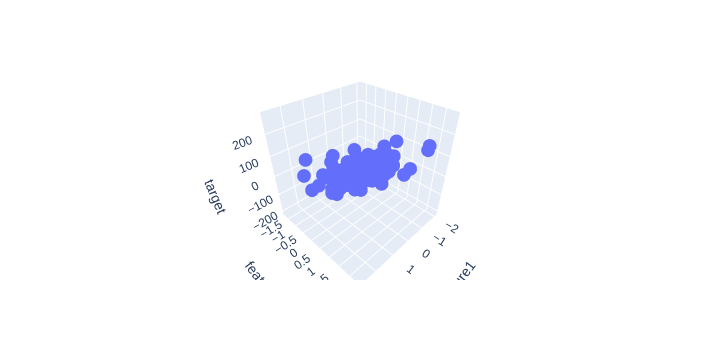

In [6]:

fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.show()
     

In [7]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [8]:

from sklearn.linear_model import LinearRegression
     

In [9]:

lr = LinearRegression()

In [10]:

lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = lr.predict(X_test)

In [12]:

print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))
     

MAE 49.16008728052867
MSE 3188.2330029868026
R2 score 0.7306430617313313


In [16]:

# 1. Define ranges
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)

# 2. Create grid with correct (x, y) order
xGrid, yGrid = np.meshgrid(x, y)

# 3. Flatten and stack to create (100, 2) input for the model
# np.c_ is the standard way to create coordinate pairs
final = np.c_[xGrid.ravel(), yGrid.ravel()]

# 4. Predict and reshape using the original grid's shape
# Reshaping to xGrid.shape is safer than hardcoding (10, 10)
z_final = lr.predict(final).reshape(xGrid.shape)

z = z_final

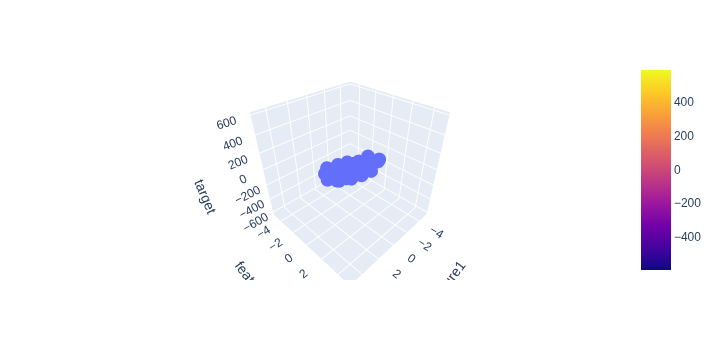

In [17]:

fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()
     

In [18]:
lr.coef_

array([34.17837757, 84.32419568])

In [19]:

lr.intercept_

np.float64(-3.1464387091890167)

In [20]:
class MeraLR:
    
    def __init__(self):
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        
        num = 0
        den = 0
        
        for i in range(X_train.shape[0]):
            
            num = num + ((X_train[i] - X_train.mean())*(y_train[i] - y_train.mean()))
            den = den + ((X_train[i] - X_train.mean())*(X_train[i] - X_train.mean()))
        
        self.m = num/den
        self.b = y_train.mean() - (self.m * X_train.mean())
        print(self.m)
        print(self.b)       
    
    def predict(self,X_test):
        
        print(X_test)
        
        return self.m * X_test + self.b

In [21]:
df = pd.read_csv('placement.csv')

In [22]:
X = df.iloc[:,0].values
y = df.iloc[:,1].values

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [24]:
lr = MeraLR()

In [25]:
lr.fit(X_train,y_train)

0.5579519734250721
-0.8961119222429152


In [26]:
print(lr.predict(X_test[0]))

8.58
3.891116009744203
